## Dataset Description: April 2015 Nepal Earthquake (Gorkha Earthquake)

This dataset covers the **April 25, 2015 Nepal earthquake**, also known as the **Gorkha earthquake**, one of the most destructive seismic events in Nepal’s history.

### Event Overview
The earthquake occurred on **25 April 2015 at 11:56 NST** with a magnitude of **Mw 7.8–7.9 (or Ms 8.1)** and a maximum intensity of **X (Extreme)**. The epicenter was near **Barpak in the Gorkha District**, about **85 km northwest of Kathmandu**, with a shallow depth of around **8.2 km**.

### Impact
The disaster affected **Nepal, India, China, and Bangladesh**, causing:
- Nearly **8,962 deaths**
- Around **21,952 injuries**
- Massive displacement, with hundreds of thousands left homeless

### Damage
Severe destruction occurred across Nepal, including collapse of entire villages and major damage to UNESCO World Heritage Sites in the Kathmandu Valley, such as:
- Durbar Squares (Kathmandu, Patan, Bhaktapur)
- Major temples and stupas
- The historic Dharahara Tower

### Aftershocks and Secondary Effects
The earthquake triggered:
- A deadly avalanche on **Mount Everest** (22 deaths)
- A major avalanche in **Langtang Valley** (around 250 missing)
- Multiple aftershocks, including a **Mw 7.3 event on 12 May 2015**

## Project Overview

In this project, we will explore data related to the **April 2015 Nepal (Gorkha) earthquake**, one of the most destructive seismic events in recent history.

The goal is to perform **exploratory data analysis (EDA)** on building damage data and understand the key factors that influenced structural failure during the earthquake.

### Objective
We will build a **classification model** to predict the **likelihood of a building suffering severe damage** based on its structural and environmental features.

### Key Tasks
- Explore and analyze earthquake building damage data  
- Identify patterns and relationships between features and damage levels  
- Engineer relevant features for modeling  
- Train a classification model to predict severe building damage risk  
- Evaluate model performance using appropriate metrics  

### Outcome
The final model will help estimate the probability of severe damage to buildings during an earthquake, supporting **disaster preparedness and risk assessment efforts**.

# Importing Data

In [1]:
import pandas as pd 
import numpy as np
import pyodbc
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from sqlalchemy import create_engine
sys.path.append(str(Path().resolve().parent))
from src.DataModule import DataHandler


In [2]:
# Drivers on my machine
print(pyodbc.drivers())

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [4]:
# Connecting to the database using our DataHandler class
data_handler = DataHandler(server=r"localhost\SQLEXPRESS", driver="ODBC Driver 18 for SQL Server", database="MyDatabase")
final_data = data_handler.read_sql_table("dbo.NepalEarhquakeDamage2015")
final_data.head()


,building_id,district_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,condition_post_eq,damage_grade
0,120101000011,12,1,1,9,288,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Used in risk,Grade 3
1,120101000021,12,1,1,15,364,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 5
2,120101000031,12,1,1,20,384,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 2
3,120101000041,12,1,1,20,312,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 2
4,120101000051,12,1,1,30,308,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 1


In [ ]:
# Save the data to a csv file in 'data/raw' directory
final_data.to_csv("../data/raw/earthquake_data.csv", index=False)

## Dataset

The dataset was originally stored in a local SQL Server database.

For reproducibility, the data has been exported to CSV format and is available in:

data/raw/earthquake_data.csv

# Dataset Description

This project uses the Nepal Earthquake Damage Dataset (2015), obtained from the Nepal Earthquake 2015 Post Disaster Needs Assessment portal.

The dataset contains 17 features describing building characteristics before and after the earthquake, including:

- building_id: Unique building identifier
- district_id: District code
- count_floors_pre_eq: Number of floors before earthquake
- count_floors_post_eq: Number of floors after earthquake
- age_building: Building age in years
- ...
- damage_grade: Damage assessment grade assigned by surveyors

Target Variable:
- damage_grade

In [5]:
# Load the data from our csv file
data = pd.read_csv("../data/raw/earthquake_data.csv", index_col="building_id")
data.head()

,district_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,condition_post_eq,damage_grade
building_id,,,,,,,,,,,,,,,,
120101000011,12,1,1,9,288,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Used in risk,Grade 3
120101000021,12,1,1,15,364,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 5
120101000031,12,1,1,20,384,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 2
120101000041,12,1,1,20,312,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 2
120101000051,12,1,1,30,308,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 1


In [6]:
data.info()

<class 'pandas.DataFrame'>
Index: 762106 entries, 120101000011 to 366709001281
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   district_id             762106 non-null  int64
 1   count_floors_pre_eq     762106 non-null  int64
 2   count_floors_post_eq    762106 non-null  int64
 3   age_building            762106 non-null  int64
 4   plinth_area_sq_ft       762106 non-null  int64
 5   height_ft_pre_eq        762106 non-null  int64
 6   height_ft_post_eq       762106 non-null  int64
 7   land_surface_condition  762106 non-null  str  
 8   foundation_type         762106 non-null  str  
 9   roof_type               762106 non-null  str  
 10  ground_floor_type       762106 non-null  str  
 11  other_floor_type        762106 non-null  str  
 12  position                762105 non-null  str  
 13  plan_configuration      762105 non-null  str  
 14  condition_post_eq       762106 non-null  str  
 15 

### Study Area

This project focuses on : (`district_id = 36`), ***'GORKHA'*** one of the districts most severely affected by the 2015 Nepal earthquake. By concentrating on buildings in Gorkha, we aim to better understand the relationship between building characteristics and earthquake damage levels.

In [7]:
data["district_id"].value_counts()

district_id
24    98019
31    90994
30    89122
23    88741
36    78074
28    77148
20    68750
22    60639
21    58623
12    39352
29    12644
Name: count, dtype: int64

In [8]:
# Mask for buildings located in "GORKHA"
data = data[data["district_id"]==36]
data.head()

,district_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,condition_post_eq,damage_grade
building_id,,,,,,,,,,,,,,,,
360106001171,36,2,0,4,280,18,0,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Rubble unclear,Grade 5
360106001181,36,1,0,15,120,18,0,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Attached-1 side,Rectangular,Damaged-Rubble unclear,Grade 5
360107000161,36,2,0,25,300,14,0,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Rubble unclear,Grade 5
360107000381,36,2,0,22,155,16,0,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Rubble clear,Grade 5
360202000691,36,2,0,20,240,14,0,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Brick/Stone,TImber/Bamboo-Mud,Attached-1 side,Rectangular,Damaged-Rubble unclear,Grade 5


In [9]:
data.shape

(78074, 16)

### Target Variable Encoding

The original `damage_grade` variable contains five levels (1–5) representing the severity of building damage. To formulate a binary classification problem, it was encoded as follows:

- **0**: Damage grade ≤ 3 (non-severe damage)
- **1**: Damage grade > 3 (severe damage)

The resulting target variable indicates whether a building suffered severe structural damage during the earthquake.

In [10]:
# encoding damage_grade columns, our target column
data["damage_grade"]=data["damage_grade"].str[-1].astype(int)

In [11]:
data["damage_grade"].dtype

dtype('int64')

In [12]:
# extract severe_damage column
data["severe_damage"] = data["damage_grade"].apply(lambda x: x>3).astype(int)

## Class Distribution Analysis

Before building a binary classification model, it is important to examine the distribution of the target classes (positive and negative). Class imbalance can significantly affect model performance and may lead to misleading evaluation results if accuracy is used as the sole evaluation metric.

For imbalanced datasets, metrics such as **Precision**, **Recall**, **F1-score**, and **PR-AUC** often provide a more reliable assessment of model performance than accuracy alone. Understanding the class distribution also helps inform decisions regarding model selection, resampling techniques, class weighting, and threshold optimization.

Therefore, analyzing the balance between classes is a critical step in the binary classification workflow, as it influences both the evaluation strategy and the overall modeling approach.

In [13]:
data["severe_damage"].value_counts()

severe_damage
1    49661
0    28413
Name: count, dtype: int64

Since the target classes are relatively balanced, **Accuracy** can be used as the primary evaluation metric during the model evaluation phase. In balanced classification problems, accuracy provides a reliable measure of overall model performance because both classes are represented proportionally in the dataset.

Therefore, after building the classification models, we will use **Accuracy Score** as the main metric to evaluate and compare their performance.

## Exploratory Data Analysis (EDA)

In this section, we perform exploratory data analysis to better understand the dataset and identify potential issues that may affect model performance. Specifically, we will:

- Detect potential data leakage.
- Examine multicollinearity among features.
- Identify low- and high-cardinality categorical variables.
- Explore feature distributions and relationships with the target variable.

These steps help improve feature selection and contribute to building a more reliable predictive model.

In [14]:
# Leakage
data.columns

Index(['district_id', 'count_floors_pre_eq', 'count_floors_post_eq',
       'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq',
       'height_ft_post_eq', 'land_surface_condition', 'foundation_type',
       'roof_type', 'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'condition_post_eq', 'damage_grade',
       'severe_damage'],
      dtype='str')

# Leakage
As shown above, any feature containing information collected *[after]* (post_eq) the earthquake introduces data leakage, as it provides information that would not be available at the time of prediction. Therefore, variables describing post-earthquake building characteristics are considered leaky features and will be removed from the analysis to ensure a realistic predictive modeling process.

In [15]:
# Drop the leaky columns
data.drop(columns=["count_floors_post_eq", "height_ft_post_eq", "condition_post_eq"], inplace=True)

# Mutlicollinearity

In [16]:
# Mutlicollinearity
corelation = data.select_dtypes(include=["number", "int64"]).drop(columns=["severe_damage","district_id", "damage_grade"]).corr()
corelation

,count_floors_pre_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq
count_floors_pre_eq,1.000000,0.062670,0.196953,0.749044
age_building,0.062670,1.000000,-0.019476,0.047666
plinth_area_sq_ft,0.196953,-0.019476,1.000000,0.286794
height_ft_pre_eq,0.749044,0.047666,0.286794,1.000000


It is clear that `count_floors_pre_eq` and `height_ft_pre_eq` exhibit a strong positive relationship, suggesting the presence of multicollinearity between these features. This is expected, as taller buildings generally tend to have more floors.

To better assess the strength of this relationship and identify any additional correlations among the numerical features, we will visualize the correlation matrix using a heatmap.

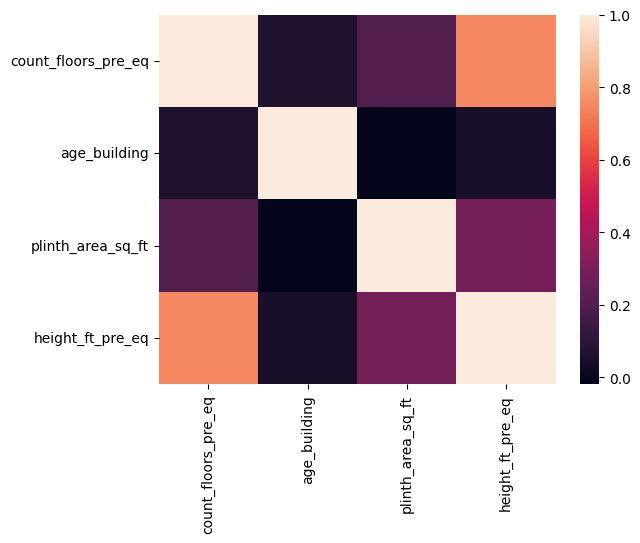

In [17]:
sns.heatmap(corelation);
plt.savefig("../reports/figures/corelation_heatmap.png", dpi=150)

Since `count_floors_pre_eq` and `height_ft_pre_eq` are highly correlated, this indicates multicollinearity between the two features.

When handling such cases, the decision to drop one feature of them  `based  on its correlation with the target variable.` 

Also it's important to keep eye on ***Information richness*** of the feature itself

In [23]:
print(f"The corelation between the target variabe and 'count_floors_pre_eq' feature is: {round(data["severe_damage"].corr(data["count_floors_pre_eq"]),3)}")
print(f"The corelation between the target variabe and 'height_ft_pre_eq' feature is: {round(data["severe_damage"].corr(data["height_ft_pre_eq"]),3)}")

The corelation between the target variabe and 'count_floors_pre_eq' feature is: 0.01
The corelation between the target variabe and 'height_ft_pre_eq' feature is: -0.039


It is clear that `height_ft_pre_eq` shows a relatively strong correlation with the target variable. In addition, since it is a continuous feature, it provides richer and more detailed information compared to discrete variables such as `count_floors_pre_eq`.

For this reason, `height_ft_pre_eq` is considered a more informative predictor and will be retained in the modeling process.

Even when the relationship between a feature and the target is negative, it remains valuable for prediction. The sign of the correlation only indicates the direction of the relationship, while the magnitude reflects its strength.

Therefore, a strong negative correlation still provides useful information to the model, as it helps capture meaningful patterns between the feature and the target variable.

In [24]:
data.drop(columns="count_floors_pre_eq", inplace=True)

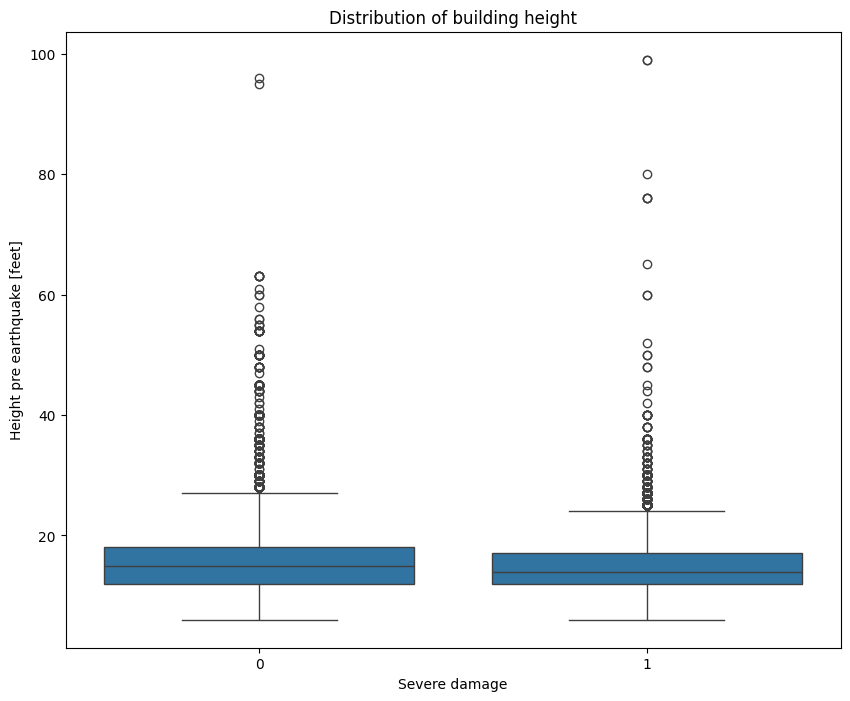

In [25]:
plt.figure(figsize=(10,8))
sns.boxplot(data=data, x="severe_damage", y= "height_ft_pre_eq")
plt.xlabel("Severe damage")
plt.ylabel("Height pre earthquake [feet]")
plt.title("Distribution of building height");

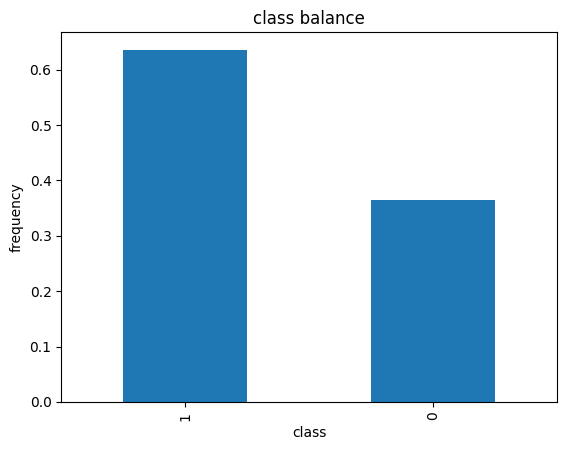

In [ ]:
# Class balance
data["severe_damage"].value_counts(normalize=True).plot(
    kind="bar",
    xlabel="class",
    ylabel="frequency",
    title="class balance"
);
plt.savefig("../reports/figures/majority_minority_class.png", dpi=150)

In [26]:
majority_class_prop, minority_class_prop = data["severe_damage"].value_counts(normalize=True)
majority_class_prop, minority_class_prop


(0.6360760304326665, 0.3639239695673336)

From the bar chart above, we can observe that the dataset shows a reasonable balance between the majority class (1) and the minority class (0). This is beneficial for model training, as it reduces the risk of bias toward one class and helps improve the model’s ability to generalize effectively.

## Relationship Between Foundation Type and Target Variable

In this section, I will explore the relationship between `foundation_type` and the target variable (`severe_damage`) to understand how different foundation types are associated with earthquake damage levels.

In [29]:
# Pivot table
foundation_pivot = pd.pivot_table(
    data, index="foundation_type", values="severe_damage", aggfunc=np.mean
).sort_values(by="severe_damage")
foundation_pivot

,severe_damage
foundation_type,
RC,0.027134
Bamboo/Timber,0.321429
Cement-Stone/Brick,0.410200
Mud mortar-Stone/Brick,0.684101
Other,0.801020


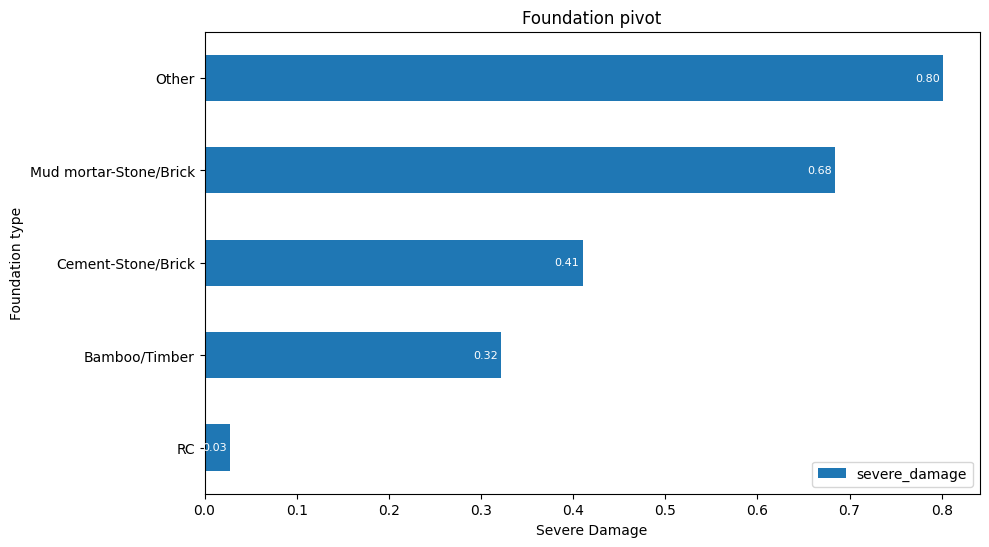

In [28]:
# Plot the foundation pivot
fig, ax = plt.subplots(figsize=(10,6))
foundation_pivot.plot(
    ax=ax,
    kind="barh",
    xlabel="Severe Damage",
    ylabel="Foundation type",
    title = "Foundation pivot"
)
ax.bar_label(ax.containers[0], label_type="edge", padding=-20, color="white", fmt="%.2f", fontsize=8 );

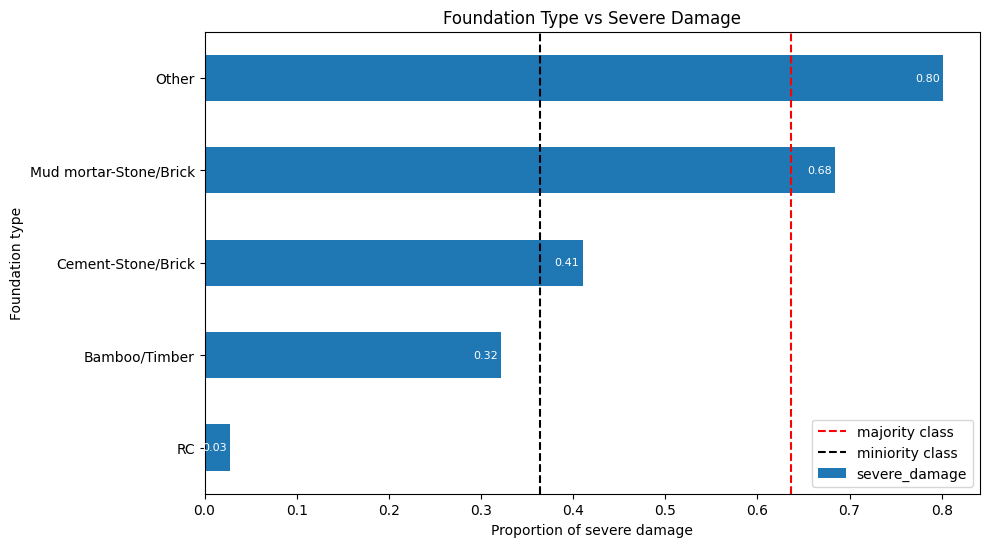

In [30]:
# Adding the majority class and minority class to the plot
fig, ax = plt.subplots(figsize=(10,6))
foundation_pivot.plot(ax=ax,kind="barh", legend=False)
ax.axvline(majority_class_prop, linestyle="--", color="red", label="majority class")
ax.axvline(minority_class_prop, linestyle="--", color="black", label="miniority class")
ax.set_xlabel("Proportion of severe damage")
ax.set_ylabel("Foundation type")
ax.set_title("Foundation Type vs Severe Damage")
ax.bar_label(ax.containers[0], label_type="edge", padding=-20, color="white", fmt="%.2f", fontsize=8 );
ax.legend();
plt.savefig("../reports/figures/pivot_foundation_maj_min_class.png", dpi=150, bbox_inches="tight")



This visualization provides an intuitive understanding of how different foundation types influence the likelihood of severe damage. Foundation types with values above the overall reference lines are associated with an increased probability of severe damage, while those below the reference lines indicate a reduced likelihood. This helps identify which foundation types are more resilient or more vulnerable to earthquake damage.

## Data Wrangling Function

After completing the exploratory data analysis (EDA), it is beneficial to encapsulate all data preprocessing steps into a single wrangling function in a  `DataHandler class` which can be found inside the `'src'` directory in `'DataModule'`. This ensures consistency, reproducibility, and easier integration into a machine learning pipeline.

The function will handle data cleaning, feature selection, and any necessary transformations to produce a clean dataset ready for modeling.

In [31]:
df = data_handler.wrangle_data("../data/raw/earthquake_data.csv", index="building_id")
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,severe_damage
building_id,,,,,,,,,,,
360106001171,4,280,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,1
360106001181,15,120,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Attached-1 side,Rectangular,1
360107000161,25,300,14,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,1
360107000381,22,155,16,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,1
360202000691,20,240,14,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Brick/Stone,TImber/Bamboo-Mud,Attached-1 side,Rectangular,1


In [121]:
df.to_csv("../data/processed/clean_df.csv")

In [32]:
df.shape

(78074, 11)

In [33]:
# Outliers
# Numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).drop(columns="severe_damage")
num_cols

,age_building,plinth_area_sq_ft,height_ft_pre_eq
building_id,,,
360106001171,4,280,18
360106001181,15,120,18
360107000161,25,300,14
360107000381,22,155,16
360202000691,20,240,14
...,...,...,...
366709001241,60,165,18
366709001251,35,342,18
366709001261,35,342,18


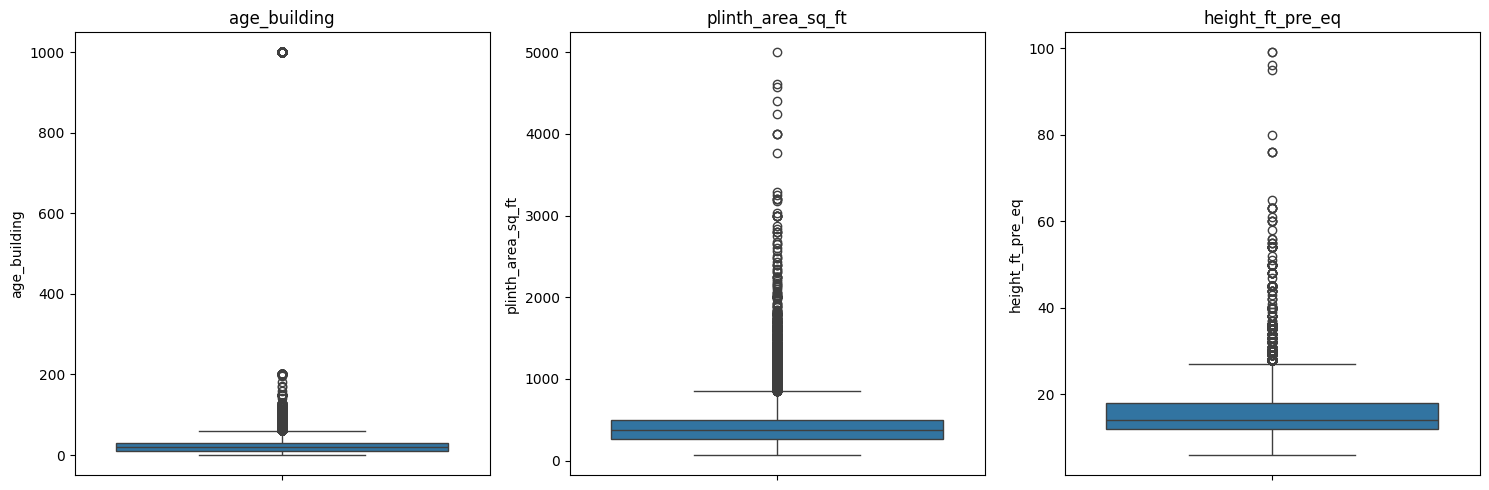

In [34]:
fig,axes = plt.subplots(1,len(num_cols.columns), figsize=(15,5))
for ax, col in zip(axes, num_cols.columns):
    sns.boxplot(ax=ax, y=num_cols[col])
    ax.set_title(col)


plt.tight_layout()
plt.show()

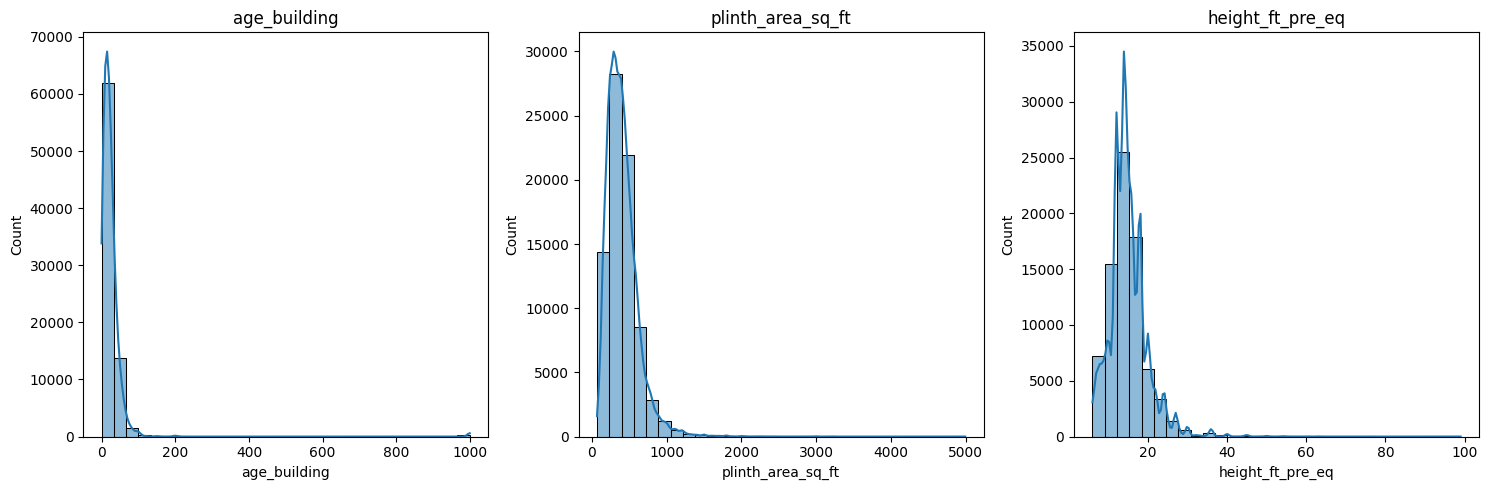

In [37]:
fig,axes = plt.subplots(1,len(num_cols.columns), figsize=(15,5))
for ax, col in zip(axes, num_cols.columns):
    sns.histplot(num_cols[col], ax=ax,  kde=True, bins=30)
    ax.set_title(col)


plt.tight_layout()
plt.show()

From the graphs above, we can see that the three numerical columns in our dataset contain outliers, and each feature has a different scale.

To handle this, I will use **RobustScaler** instead of **StandardScaler** in the pipeline. RobustScaler is less sensitive to outliers because it uses the median and IQR rather than the mean and standard deviation.

Scaling also helps optimization algorithms like gradient descent converge more efficiently.

In [40]:
# Categorical cols
cat_cols = df.select_dtypes(include=["object", "str", "category"])
cat_cols

,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration
building_id,,,,,,,
360106001171,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular
360106001181,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Attached-1 side,Rectangular
360107000161,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular
360107000381,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular
360202000691,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Brick/Stone,TImber/Bamboo-Mud,Attached-1 side,Rectangular
...,...,...,...,...,...,...,...
366709001241,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Attached-2 side,Rectangular
366709001251,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Attached-1 side,Rectangular
366709001261,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,Rectangular


In [41]:
# Checking for nulls
df.isnull().sum()

age_building              0
plinth_area_sq_ft         0
height_ft_pre_eq          0
land_surface_condition    0
foundation_type           0
roof_type                 0
ground_floor_type         0
other_floor_type          0
position                  0
plan_configuration        0
severe_damage             0
dtype: int64

# Data split

In [42]:
# Vertical split
X = df.drop(columns="severe_damage")
y=df["severe_damage"]

In [43]:
# Horizontal split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

It is important to note that the dataset was split prior to building the data pipeline in order to prevent data leakage during model training. This ensures that the transformations applied within the pipeline are learned exclusively from the training set, preserving the integrity of the evaluation process and maintaining a fair assessment of the model’s performance.

# Data Pipeline and Model Building

In [45]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  RobustScaler
from category_encoders import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

numerical_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore",use_cat_names=True))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, num_cols.columns),
    ("cat", categorical_transformer, cat_cols.columns)
], remainder="passthrough")

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("lr", LogisticRegression(max_iter=1000))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [46]:
# Establishing the baseline accuracy for our model
# naive model
acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline ccuracy: {round(acc_baseline,2)}")

Baseline ccuracy: 0.63


In [47]:
# fit the model 
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [48]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_train, pipeline.predict(X_train))
print(f"Training ccuracy: {round(acc_train,3)}")

Training ccuracy: 0.704


In [49]:
acc_test = pipeline.score(X_test, y_test)
print(f"Test ccuracy: {round(acc_test,2)}")

Test ccuracy: 0.71


### Model Performance

Our model achieved higher accuracy than the baseline on both the training and test datasets, indicating improved performance and good generalization compared to a naive prediction approach.

In [50]:
# the probablity prediction
pipeline.predict_proba(X_train)[:5]

array([[0.34352848, 0.65647152],
       [0.47391024, 0.52608976],
       [0.30089934, 0.69910066],
       [0.23973872, 0.76026128],
       [0.12742999, 0.87257001]])

# Communicating Results

In [58]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_names = [name.split("__",1)[1] for name in feature_names]
feature_names

['age_building',
 'plinth_area_sq_ft',
 'height_ft_pre_eq',
 'land_surface_condition_Flat',
 'land_surface_condition_Steep slope',
 'land_surface_condition_Moderate slope',
 'foundation_type_Mud mortar-Stone/Brick',
 'foundation_type_Cement-Stone/Brick',
 'foundation_type_RC',
 'foundation_type_Bamboo/Timber',
 'foundation_type_Other',
 'roof_type_Bamboo/Timber-Heavy roof',
 'roof_type_Bamboo/Timber-Light roof',
 'roof_type_RCC/RB/RBC',
 'ground_floor_type_Mud',
 'ground_floor_type_RC',
 'ground_floor_type_Brick/Stone',
 'ground_floor_type_Timber',
 'ground_floor_type_Other',
 'other_floor_type_Not applicable',
 'other_floor_type_Timber-Planck',
 'other_floor_type_TImber/Bamboo-Mud',
 'other_floor_type_RCC/RB/RBC',
 'position_Not attached',
 'position_Attached-1 side',
 'position_Attached-2 side',
 'position_Attached-3 side',
 'plan_configuration_Rectangular',
 'plan_configuration_Square',
 'plan_configuration_Multi-projected',
 'plan_configuration_L-shape',
 'plan_configuration_T-shap

In [59]:
importances = pipeline.named_steps["lr"].coef_[0]
importances


array([ 0.02023256,  0.05651657,  0.01375875, -0.39607389,  0.18216211,
       -0.20180907,  0.73079552,  0.06272669, -1.46975967, -0.64733133,
        0.90784794,  0.32183467,  0.16419599, -0.90175152,  0.10191514,
       -0.86133777,  0.22542306,  0.57904952, -0.46077081, -0.16595708,
        0.38887989, -0.00749187, -0.6311518 ,  0.02961506,  0.12387439,
        0.02889322, -0.59810353,  0.48093673,  0.30841483, -0.83766634,
       -0.17406263,  0.31343778, -0.50329011, -0.08430279, -0.02263276,
       -0.06121453,  0.16465895])

In [60]:
odds_ratios = pd.Series(np.exp(importances), index=feature_names).sort_values()
odds_ratios.tail()


other_floor_type_Timber-Planck            1.475327
plan_configuration_Rectangular            1.617589
ground_floor_type_Timber                  1.784342
foundation_type_Mud mortar-Stone/Brick    2.076732
foundation_type_Other                     2.478982
dtype: float64

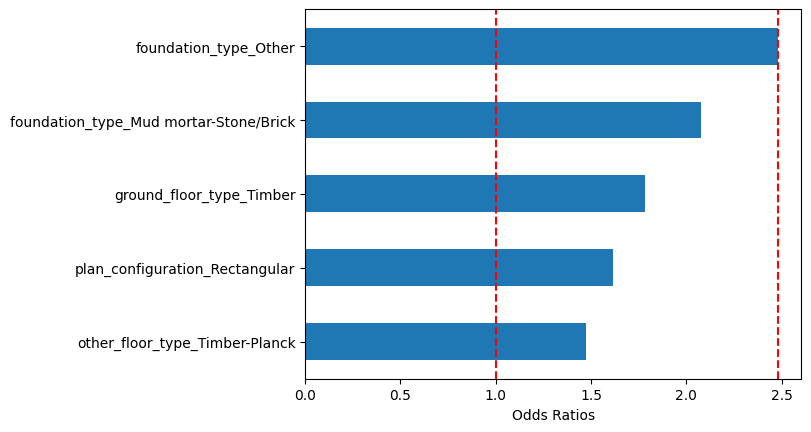

In [62]:
# Horizontal bar-chart for five largest coofficients
odds_ratios.tail(5).plot(
    
    kind="barh"
)
plt.axvline(x=1.0, linestyle="--", color="red")
plt.axvline(odds_ratios.loc["foundation_type_Other"], linestyle="--", color="red")
plt.xlabel("Odds Ratios");
plt.savefig("../reports/figures/odds_ratios_big_5.png", dpi=150,bbox_inches="tight")

### Interpretation of Odds Ratios

The odds ratio plot provides insight into how each feature influences the likelihood of a building experiencing severe damage. Features with an odds ratio greater than 1 are associated with higher odds of severe damage, while features with an odds ratio less than 1 are associated with lower odds relative to their respective reference categories.

For example, the feature `foundation_type_other` has an odds ratio of approximately 2.5. This indicates that, holding all other variables constant, buildings with this foundation type have 2.5 times the odds of experiencing severe damage compared to buildings in the reference category.


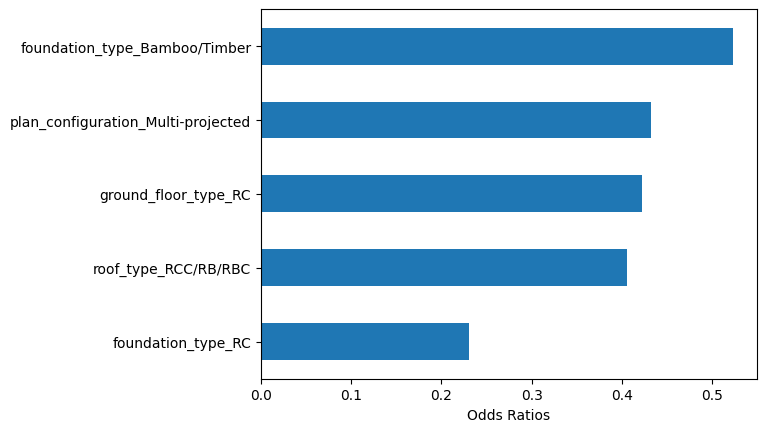

In [63]:
odds_ratios.head().plot(
    
    kind="barh"
)
plt.xlabel("Odds Ratios");
plt.savefig("../reports/figures/odds_ratios_less_5.png", dpi=150, bbox_inches="tight")


In contrast, the feature `foundation_type_RC` has an odds ratio of approximately 0.24. This suggests that, all other things being equal, buildings with a reinforced concrete (RC) foundation have only 24% of the odds of experiencing severe damage compared to the reference category. Equivalently, this represents an approximate **76% reduction in the odds** of severe damage.


As a general guideline:

- **Odds Ratio > 1**: Associated with higher odds of the outcome.
  - Percentage increase in odds = \((OR - 1) \times 100\%\)

- **Odds Ratio < 1**: Associated with lower odds of the outcome.
  - Percentage decrease in odds = \((1 - OR) \times 100\%\)

These interpretations provide valuable insight into which building characteristics are associated with a higher or lower risk of severe damage.

And that's what we already discovered in the pivot table bar chart above

<img src="../reports/figures//pivot_foundation_maj_min_class.png" width="700"/>

In [71]:
# saving the Pipeline
import joblib
joblib.dump(pipeline, "../models/Logistic_reg_pipeline.joblib")

['../models/Logistic_reg_pipeline.joblib']

# Decision Tree Model - Cross Validation

In [ ]:
# # Split the training data into trainig set and cross validation set
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Categorical Encoding Strategy

For tree-based models like Decision Trees, **Ordinal Encoding** can be used since these models are generally not sensitive to the numerical ordering of categories.

However, for linear models such as **Logistic Regression**, Ordinal Encoding is not suitable for nominal variables because it introduces a false sense of order. Instead, **One-Hot Encoding** is preferred to represent categories independently.

In [64]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
model = make_pipeline(
    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    DecisionTreeClassifier(random_state=42)
)

# fit the model to the training data
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are i

In [65]:
# Model evaluation
acc_training = accuracy_score(y_train, model.predict(X_train))
acc_test = model.score(X_test, y_test)

print(f"Training Acuuracy: {round(acc_training,2)}")
print(f"Test Acuuracy: {round(acc_test,2)}")

Training Acuuracy: 0.98
Test Acuuracy: 0.64


In [66]:
# Evaluating using different folds of the data
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model,X=X_train, y=y_train, cv= 10, scoring="accuracy")
acc_val= scores.mean()
print(f"Cross validation Acuuracy: {round(acc_val,2)}")


Cross validation Acuuracy: 0.64


# OVERFITTING
## 🛠️ Model Diagnostics & Hyperparameter Tuning

### 1. The Problem: Overfitting
Our **Decision Tree Classifier** is overfitting, demonstrating strong training performance but poor generalization on validation data.

### 2. Root Cause Hypothesis
This high variance is likely driven by an unconstrained **tree depth (`max_depth`)**, allowing the tree to grow too complex and memorize statistical noise.

### 3. Strategy: Cross-Validation & Tuning
To fix this, we will implement **k-fold Cross-Validation** to systematically tune key regularization hyperparameters. This will help find the optimal bias-variance tradeoff:

*   **`max_depth`**: Caps the tree's growth to prevent overly complex branches.


In [67]:
# Current Depth [model[-1].get_depth()]
cur_depth = model.named_steps["decisiontreeclassifier"].get_depth()
cur_depth

59

* **The Impact:** A depth of 53 confirms severe overfitting. The tree is far too complex, meaning it has memorized training noise instead of learning generalizable patterns.
* **Next Step:** We will use cross-validation to prune the tree, targeting a heavily constrained `max_depth` range (e.g., 3 to 15) to improve validation performance.

In [68]:
depth_hyperparams = range(1,50,2)
depth_hyperparams

range(1, 50, 2)

In [69]:
# Cross Validation - Model selecation
trainig_acc = []
validation_acc = []
for d in depth_hyperparams:
    test_model = make_pipeline(
        OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        DecisionTreeClassifier( max_depth=d, random_state=42)
    )
    test_model.fit(X_train, y_train)
    trainig_acc.append(test_model.score(X_train, y_train))
    validation_acc.append(cross_val_score(test_model, X_train, y_train, scoring="accuracy", n_jobs=-1).mean())



### Cross-Validation Behavior in `cross_val_score`

When the `cv` parameter is left as `None`, `cross_val_score()` automatically selects a cross-validation strategy based on the estimator type:

- For **classification estimators**, it uses `StratifiedKFold(n_splits=5)`.
- For **regression estimators**, it uses `KFold(n_splits=5)`.

If an integer value is provided for `cv` (e.g., `cv=10`), that value is used as the number of folds (`n_splits`) when constructing the corresponding cross-validator.

For example:

```python
cross_val_score(model, X, y, cv=10)

# Learning curve

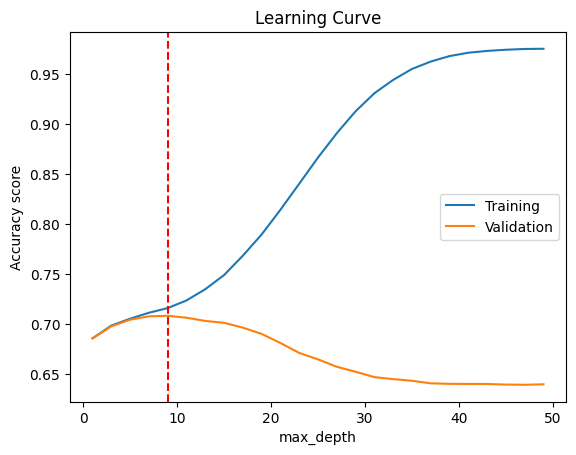

In [70]:
# PLotting the learning curve to pick the best max_depth for our model
plt.figure()
plt.plot(depth_hyperparams, trainig_acc, label="Training")
plt.plot(depth_hyperparams, validation_acc, label="Validation")
plt.xlabel("max_depth")
plt.ylabel("Accuracy score")
plt.title("Learning Curve")
plt.axvline(x=9, linestyle="--", color="red")
plt.legend();
plt.savefig("../reports/figures/Learning_curve_max_depth.png", dpi=150)


## 🎯 Optimal Hyperparameter Selection

Based on the learning curve plotted above, the optimal value for **`max_depth`** is **`9`**.

### Justification:
* **The Sweet Spot:** At a depth of 9, the model achieves the peak **Validation Accuracy**, maximizing its ability to generalize to unseen data.
* **Balanced Complexity:** This structural constraint effectively resolves our overfitting issue. It prevents the tree from expanding into a high-variance model (like our unconstrained baseline depth of 53) while maintaining robust, stable performance across both datasets.

In [73]:
# Building the model with the best max_depth
model_dtc = make_pipeline(
    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    DecisionTreeClassifier(max_depth=9, random_state=42)
)
model_dtc.fit(X_train, y_train)
print(f"Training accuracy: {round(model_dtc.score(X_train,y_train ),2)}")



Training accuracy: 0.72


In [82]:
# now we can test our model performance on the test set
print(f"Test accuracy: {round(model_dtc.score(X_test,y_test ),2)}")

Test accuracy: 0.72


In [74]:
# saving the Decision tree classifier model(Pipeline)
joblib.dump(model_dtc, "../models/decision_tree_pipeline.joblib")

['../models/decision_tree_pipeline.joblib']

# Communicating results (Decision tree classifier)

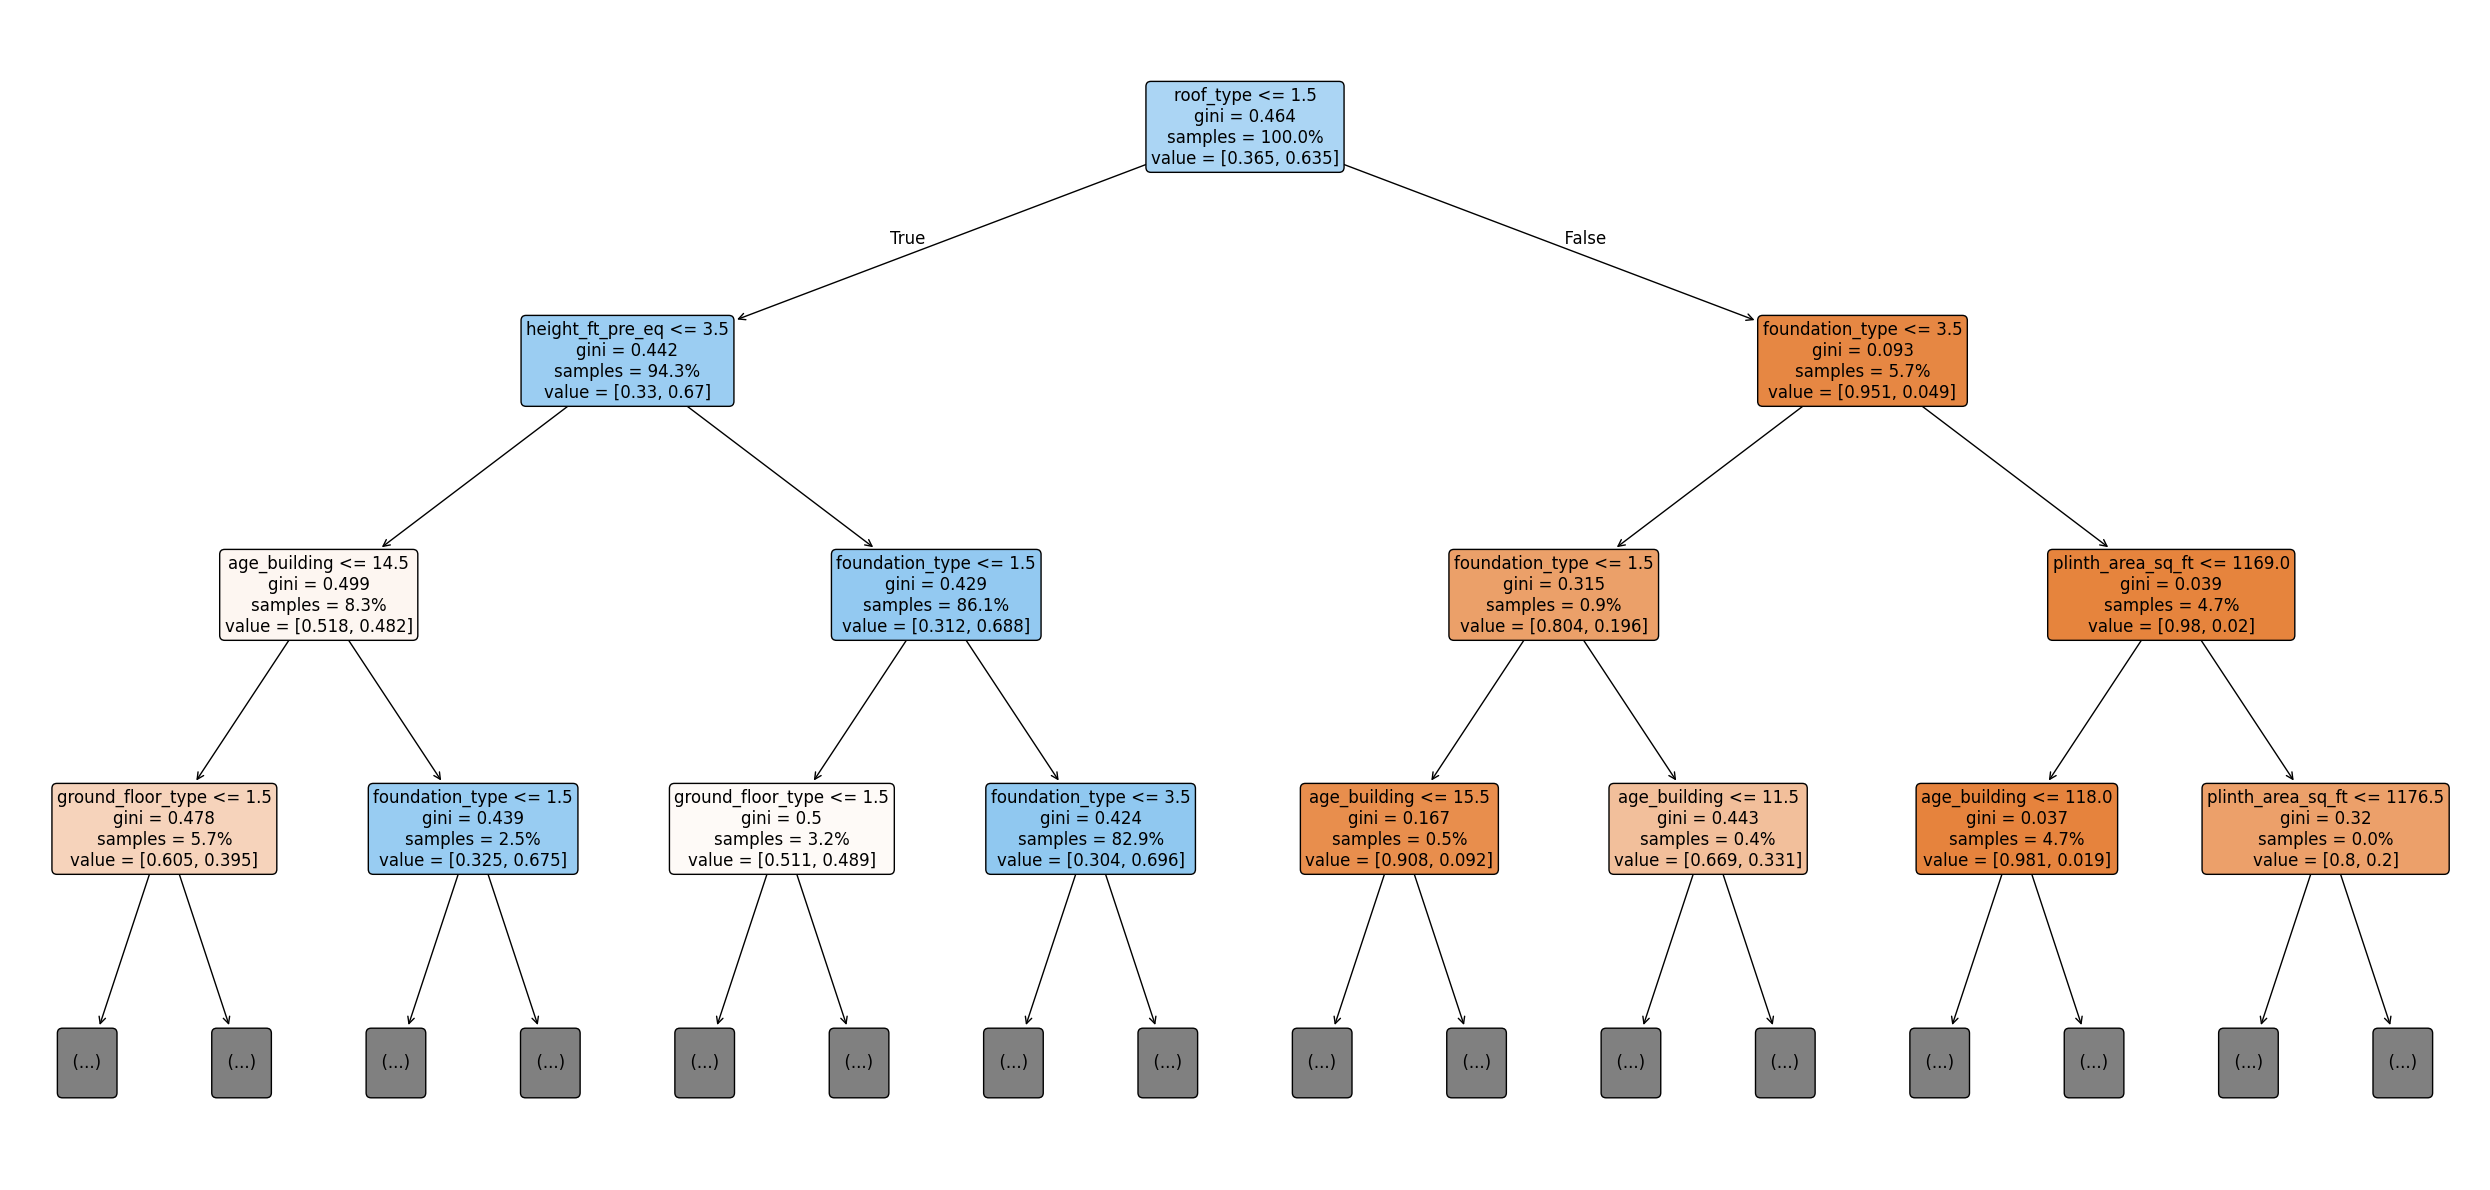

In [75]:
from sklearn.tree import plot_tree
fig,ax = plt.subplots(figsize=(25,12))
plot_tree(
    decision_tree= model_dtc.named_steps["decisiontreeclassifier"],
    feature_names=X_train.columns.to_list(),
    filled=True,
    rounded =True,
    proportion=True,
    max_depth=3, # maxdepth to show inside the tree plot
    fontsize=12,
    ax=ax
);
plt.tight_layout()
plt.savefig("../reports/figures/single_dt_plot.png", dpi=150)

In [76]:
# Importances
features = X_train.columns
dt_importances = model_dtc.named_steps["decisiontreeclassifier"].feature_importances_
dt_importances

array([0.07316213, 0.05266766, 0.14186962, 0.02249833, 0.09147938,
       0.51502762, 0.05004306, 0.04495257, 0.00500069, 0.00329893])

In [77]:
# feature importances series
dt_fea_imp = pd.Series(dt_importances, index=features).sort_values()
dt_fea_imp

plan_configuration        0.003299
position                  0.005001
land_surface_condition    0.022498
other_floor_type          0.044953
ground_floor_type         0.050043
plinth_area_sq_ft         0.052668
age_building              0.073162
foundation_type           0.091479
height_ft_pre_eq          0.141870
roof_type                 0.515028
dtype: float64

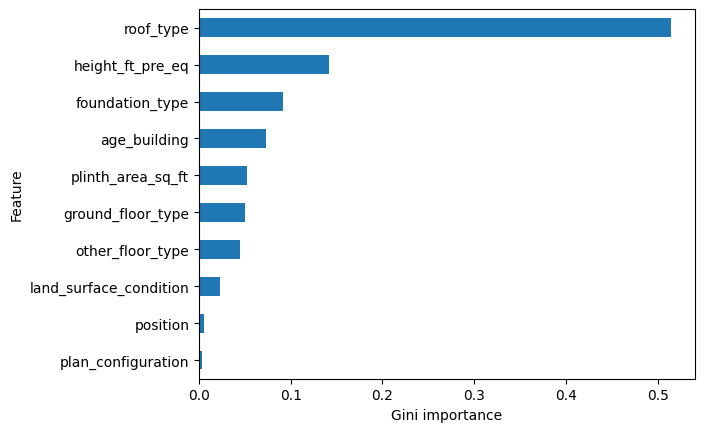

In [80]:
dt_fea_imp.plot(kind="barh")
plt.xlabel("Gini importance")
plt.ylabel("Feature");
plt.savefig("../reports/figures/dtc_feature_importances.png", dpi=150, bbox_inches="tight")


## 📊 Model Interpretability: Decision Trees vs. Logistic Regression

Understanding feature significance in a **Decision Tree** requires a fundamentally different mental model than interpreting coefficients in a **Logistic Regression**. 

### 1. Conceptual Differences
* **Logistic Regression (Coefficients):** Coefficients represent the *magnitude and direction* of a feature's effect. They dictate how much the log-odds of the target variable shift with a one-unit change in the feature (measuring predictive weight).
* **Decision Trees (Gini/Information Gain Importance):** Tree-based importances calculate the **Mean Decrease in Impurity**. Instead of showing directional impact, they measure how much a feature's splits contributed to making the resulting child nodes "purer" (more homogenous). These values are normalized, meaning all feature importances sum to 1.0 (or 100%).


### 2. Interpreting our Results: `roof_type` (= 0.50)
When our Decision Tree assigns an importance score of **0.50** to `roof_type`, it yields a very specific insight:

* **50% Contribution to Purity:** This feature alone is responsible for **50% of the total reduction in dataset impurity** achieved during the entire learning process.
* **Primary Information Driver:** It establishes `roof_type` as the dominant routing metric in the tree, meaning the model relies heavily on this specific variable to cleanly partition the data into correct target classes.
* **Zero-Sum Total (Sums to 1.0):** Because feature importance is a relative measurement of the total impurity reduction, the sum of all feature importances across the entire model will always equal exactly **1.0 (or 100%)**. Since `roof_type` accounts for 0.50, all other features in the dataset combined make up the remaining 50% of the model's total purity gains.

In [81]:
dt_importances.sum()

np.float64(1.0)

* **Zero-Sum Total (Sums to 1.0):** Because feature importance is a relative measurement of the total impurity reduction, the sum of all feature importances across the entire model will always equal exactly **1.0 (or 100%)**. A feature with a score of 0.0 means it was never chosen for a split, contributing nothing to the model's purity gains.

# Bagged Models - `Random Forest`

In [83]:
from sklearn.ensemble import RandomForestClassifier


rfc_model = make_pipeline(
    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    RandomForestClassifier() # with default n_estimators=100
)
rfc_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are i

In [84]:
# Training accuracy
rfc_train_acc = rfc_model.score(X_train, y_train)
print(f"rfc_model Training accuracy: {round(rfc_train_acc,2)}")

rfc_model Training accuracy: 0.98


In [85]:
rfc_val_scores = cross_val_score(rfc_model, X_train, y_train)
rfc_val_scores


array([0.68443804, 0.68267691, 0.68491835, 0.68371758, 0.68577376])

In [86]:
print(f"rfc_model Validation accuracy: {round(rfc_val_scores.mean(),2)}")

rfc_model Validation accuracy: 0.68


In [87]:
# Max depth and min depth among the 100 rfc single trees
rfc_trees_depth = [tree.get_depth() for tree in rfc_model.named_steps["randomforestclassifier"].estimators_]
print(f"Min Depth: {np.min(rfc_trees_depth)}")
print(f"Max Depth: {np.max(rfc_trees_depth)}")

Min Depth: 44
Max Depth: 60


The Random Forest Classifier is once again showing signs of overfitting. To address this issue and improve generalization performance, we will apply **Grid Search with Cross-Validation** to systematically tune the model’s hyperparameters and select the optimal configuration.

In [88]:
# Parameters dict
params = {
    "randomforestclassifier__n_estimators": range(25,101,25),
    "randomforestclassifier__max_depth": range(40,100,10)
}

In [95]:
from sklearn.model_selection import GridSearchCV
grid_model = GridSearchCV(
    rfc_model,
    param_grid=params,
    cv=5,
    n_jobs=1,
    verbose=1
)
grid_model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(40, 100, 10), 'randomforestclassifier__n_estimators': range(25, 101, 25)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [96]:
# Train the grid_model

grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(40, 100, 10), 'randomforestclassifier__n_estimators': range(25, 101, 25)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [97]:
cv_results = pd.DataFrame(grid_model.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.090120,0.123417,0.200235,0.024532,40,25,"{'randomforestclassifier__max_depth': 40, 'ran...",0.678915,0.678034,0.682037,0.682277,0.686254,0.681503,0.002905,18
1,5.498353,0.072995,0.316784,0.004989,40,50,"{'randomforestclassifier__max_depth': 40, 'ran...",0.683958,0.681556,0.680756,0.684278,0.686494,0.683408,0.002052,13
2,8.257650,0.122882,0.450513,0.003531,40,75,"{'randomforestclassifier__max_depth': 40, 'ran...",0.684518,0.682037,0.686760,0.685399,0.688656,0.685474,0.002214,1
3,10.767997,0.098532,0.579980,0.003894,40,100,"{'randomforestclassifier__max_depth': 40, 'ran...",0.685719,0.682357,0.685559,0.684838,0.687295,0.685153,0.001612,2
4,2.879917,0.029709,0.183703,0.002495,50,25,"{'randomforestclassifier__max_depth': 50, 'ran...",0.678274,0.678514,0.684278,0.682997,0.681691,0.681151,0.002396,20


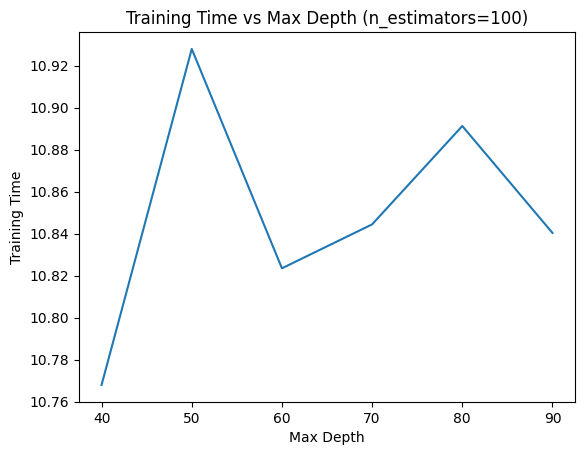

In [98]:
# As grid_model fitting took 18 minutes i will check fit time vs max_depth and n_estimators
n_estimators_mask = cv_results["param_randomforestclassifier__n_estimators"]==100

# plot fit time vs max_depth
plt.plot(
    cv_results[n_estimators_mask]["param_randomforestclassifier__max_depth"],
    cv_results[n_estimators_mask]["mean_fit_time"]
)
plt.xlabel("Max Depth")
plt.ylabel("Training Time")
plt.title("Training Time vs Max Depth (n_estimators=100)");

In [99]:
cv_results[n_estimators_mask][["mean_fit_time","param_randomforestclassifier__max_depth"]]

,mean_fit_time,param_randomforestclassifier__max_depth
3,10.767997,40
7,10.927955,50
11,10.823516,60
15,10.844429,70
19,10.891258,80
23,10.840352,90


In [100]:
grid_model.best_params_

{'randomforestclassifier__max_depth': 40,
 'randomforestclassifier__n_estimators': 75}

In [103]:
# Extracting best parameters for our random forest classifier model
print("Model best max depth is: ",grid_model.best_params_["randomforestclassifier__max_depth"])
print("Model best n_estimitaors is: ",grid_model.best_params_["randomforestclassifier__n_estimators"])

Model best max depth is:  40
Model best n_estimitaors is:  75


In [104]:
# Extracting best model from the GridSearchCv
rfc_best_model = grid_model.best_estimator_
rfc_best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are i

In [105]:
# Extractiung best score from the GridSearchCv
best_score = grid_model.best_score_
print(f"Score of the best estimator of GridSearchCV: {round(best_score,2)}")

Score of the best estimator of GridSearchCV: 0.69


In [106]:
# saving random_forest model
joblib.dump( rfc_best_model,"../models/random_forest.joblib")

['../models/random_forest.joblib']

As shown above, the single Decision Tree achieved a higher performance score (0.72) compared to the Random Forest classifier (0.69). 

Furthermore, even after hyperparameter tuning via GridSearchCV, the Random Forest model continued to exhibit signs of overfitting on the dataset.

In the next step, we will proceed to experiment with the Extreme Gradient Boosting (XGBoost) model to potentially achieve improved generalization performance and better control over model complexity.

# Boosted models - `XGBoost`

In [107]:
from xgboost import XGBClassifier

In [108]:
xgb_model = make_pipeline(
    OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
    XGBClassifier()
)

# Fit the model
xgb_model.fit(X_train,y_train)




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequent

In [109]:
print(f"XGB model training accuracy: {xgb_model.score(X_train, y_train)}")
print(f"XGB model training accuracy: {cross_val_score(xgb_model, X_train, y_train).mean()}")

XGB model training accuracy: 0.7457852351142349
XGB model training accuracy: 0.7144206332562006


In [110]:
from sklearn.model_selection import StratifiedKFold, KFold
str_kfold = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)


In [111]:
# GridSearchCV

xgb_paramas = {
    'xgbclassifier__n_estomators': range(20,80,10),
    'xgbclassifier__max_depth': range(5,31,5)
}

xgb_grid_model = GridSearchCV(
    xgb_model,
    param_grid=xgb_paramas,
    cv=str_kfold,
    n_jobs=-1,
    verbose=2
    
)
xgb_grid_model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgbclassifier__max_depth': range(5, 31, 5), 'xgbclassifier__n_estomators': range(20, 80, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [112]:
xgb_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgbclassifier__max_depth': range(5, 31, 5), 'xgbclassifier__n_estomators': range(20, 80, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [113]:
# XGB model best parameters from GridSearchCV
xgb_grid_model.best_params_

{'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estomators': 20}

In [114]:
pd.DataFrame(xgb_grid_model.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_xgbclassifier__max_depth,param_xgbclassifier__n_estomators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.317722,0.696436,0.172717,0.027350,5,20,"{'xgbclassifier__max_depth': 5, 'xgbclassifier...",0.711896,0.715098,0.717259,0.716619,0.711392,0.714453,0.002404,1
1,2.480601,0.505492,0.234528,0.073532,5,30,"{'xgbclassifier__max_depth': 5, 'xgbclassifier...",0.711896,0.715098,0.717259,0.716619,0.711392,0.714453,0.002404,1
2,2.336796,0.445238,0.208969,0.056931,5,40,"{'xgbclassifier__max_depth': 5, 'xgbclassifier...",0.711896,0.715098,0.717259,0.716619,0.711392,0.714453,0.002404,1
3,2.112293,0.611744,0.173831,0.041621,5,50,"{'xgbclassifier__max_depth': 5, 'xgbclassifier...",0.711896,0.715098,0.717259,0.716619,0.711392,0.714453,0.002404,1
4,2.065562,0.536257,0.195680,0.054261,5,60,"{'xgbclassifier__max_depth': 5, 'xgbclassifier...",0.711896,0.715098,0.717259,0.716619,0.711392,0.714453,0.002404,1


In [115]:
xgb_pipeline = xgb_grid_model.best_estimator_
xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequent

In [ ]:
# training accuracy
xgb_pipeline.score(X_train,y_train)

0.7338734209641525

In [ ]:
# test accuracy
xgb_pipeline.score(X_test,y_test)

0.7252641690682037

In [118]:
# saving the xgb model
joblib.dump(xgb_pipeline, "../models/xgb_pipeline.joblib")

['../models/xgb_pipeline.joblib']